In [3]:
print(raw.columns.tolist())
print(raw["label"].unique())
print(raw["label"].dtype)
print(len(raw))

['tweet_id', 'safe_text', 'label', 'agreement']
[]
float64
0


In [4]:
import pandas as pd
import re
import os

if os.getcwd().endswith("notebooks"):
    os.chdir("..")
print("Now working in:", os.getcwd())

raw = pd.read_csv("data/raw/Train.csv", dtype={"tweet_id": str})
val = pd.read_csv("data/processed/val.csv", dtype={"tweet_id": str})
test = pd.read_csv("data/processed/test.csv", dtype={"tweet_id": str})

print("Raw rows before filtering:", len(raw))

# Drop missing labels, keep only valid ones (-1, 0, 1) as floats
raw = raw.dropna(subset=["label"])
raw = raw[raw["label"].isin([-1.0, 0.0, 1.0])]
print("After dropping bad labels:", len(raw))

used_ids = set(val["tweet_id"]) | set(test["tweet_id"])
train_raw = raw[~raw["tweet_id"].astype(str).isin(used_ids)].copy()
print("Remaining for train:", len(train_raw))

label_map = {-1.0: 0, 0.0: 1, 1.0: 2}
train_raw["label"] = train_raw["label"].map(label_map)

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", "<url>", text)
    text = re.sub(r"@\w+", "<user>", text)
    text = re.sub(r"[^\w\s<>]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_raw["text_raw"] = train_raw["safe_text"]
train_raw["text_clean"] = train_raw["safe_text"].apply(clean_text)
train_final = train_raw[["tweet_id", "text_raw", "text_clean", "label"]]
train_final.to_csv("data/processed/train.csv", index=False)
print("Saved", len(train_final), "rows")

Now working in: c:\Users\H O P E\vaccine-sentiment-nlp
Raw rows before filtering: 10001
After dropping bad labels: 9999
Remaining for train: 6999
Saved 6999 rows


Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best params: {'svm__C': 0.1, 'tfidf__max_features': None, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 1)}
Best CV macro-F1: 0.6441
VAL macro-F1: 0.6641
              precision    recall  f1-score   support

    negative     0.3913    0.4038    0.3975       156
     neutral     0.7915    0.7840    0.7877       736
    positive     0.7148    0.7171    0.7159       608

    accuracy                         0.7173      1500
   macro avg     0.6325    0.6350    0.6337      1500
weighted avg     0.7188    0.7173    0.7180      1500

acc=0.717 macro_f1=0.634 prec=0.633 rec=0.635 train_time=0.44s


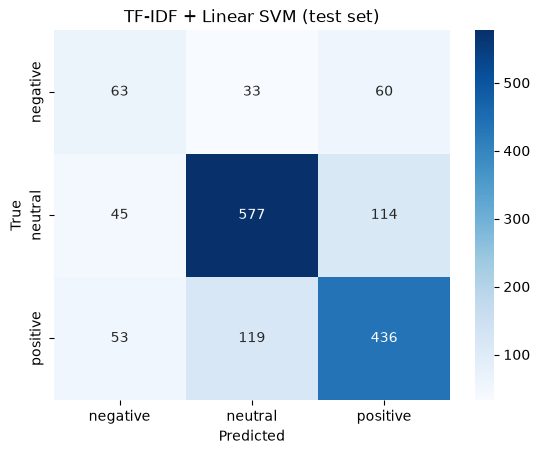

424 misclassified test tweets saved


In [5]:
import time, csv, os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, classification_report,
                             confusion_matrix)

MODEL_NAME = "tfidf_linear_svm"

# 1. Load the shared splits (do NOT re-clean or re-split)
train = pd.read_csv("data/processed/train.csv")
val   = pd.read_csv("data/processed/val.csv")
test  = pd.read_csv("data/processed/test.csv")

X_train, y_train = train["text_clean"].fillna(""), train["label"]
X_val,   y_val   = val["text_clean"].fillna(""),   val["label"]
X_test,  y_test  = test["text_clean"].fillna(""),  test["label"]

# 2. Pipeline: TF-IDF -> Linear SVM
#    class_weight="balanced" because negative is only ~10% of the data
pipe = Pipeline([
    ("tfidf", TfidfVectorizer(sublinear_tf=True)),
    ("svm", LinearSVC(class_weight="balanced", max_iter=5000)),
])

# 3. Tune on TRAIN only (5-fold CV), optimising macro-F1
param_grid = {
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__min_df": [1, 2, 5],
    "tfidf__max_features": [None, 20000],
    "svm__C": [0.1, 0.5, 1, 2],
}
grid = GridSearchCV(pipe, param_grid, scoring="f1_macro",
                    cv=StratifiedKFold(5, shuffle=True, random_state=42),
                    n_jobs=-1, verbose=1)
t0 = time.time()
grid.fit(X_train, y_train)
tuning_time = time.time() - t0
print("Best params:", grid.best_params_)
print("Best CV macro-F1:", round(grid.best_score_, 4))

# 4. Time a single clean fit with the best params (comparable to Model 1's 1.52s)
best = grid.best_estimator_
t0 = time.time()
best.fit(X_train, y_train)
train_time = time.time() - t0

# 5. Sanity check on validation, final numbers on test
val_pred = best.predict(X_val)
print("VAL macro-F1:", round(f1_score(y_val, val_pred, average="macro"), 4))

y_pred = best.predict(X_test)
names = ["negative", "neutral", "positive"]
print(classification_report(y_test, y_pred, target_names=names, digits=4))

acc  = accuracy_score(y_test, y_pred)
mf1  = f1_score(y_test, y_pred, average="macro")
prec = precision_score(y_test, y_pred, average="macro")
rec  = recall_score(y_test, y_pred, average="macro")
print(f"acc={acc:.3f} macro_f1={mf1:.3f} prec={prec:.3f} rec={rec:.3f} "
      f"train_time={train_time:.2f}s")

# 6. Append one row to results/metrics_summary.csv
os.makedirs("results/confusion_matrices", exist_ok=True)
notes = f"best params: {grid.best_params_}; grid search {tuning_time:.0f}s"
with open("results/metrics_summary.csv", "a", newline="") as f:
    csv.writer(f).writerow([MODEL_NAME, round(acc, 3), round(mf1, 3),
                            round(prec, 3), round(rec, 3),
                            round(train_time, 2), notes])

# 7. Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=names, yticklabels=names)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("TF-IDF + Linear SVM (test set)")
plt.savefig(f"results/confusion_matrices/{MODEL_NAME}.png",
            dpi=200, bbox_inches="tight")
plt.show()

# 8. Misclassified tweets, including agreement-friendly raw text, for error analysis
errs = test.assign(pred=y_pred)
errs = errs[errs["label"] != errs["pred"]][["tweet_id", "text_raw", "label", "pred"]]
errs.to_csv("results/svm_errors.csv", index=False)
print(len(errs), "misclassified test tweets saved")